###**DIP Practical-11**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

#### **Objective:**

Develop an application for Motion Estimation using Motion field and optical flow.


Base frames for motion estimation:


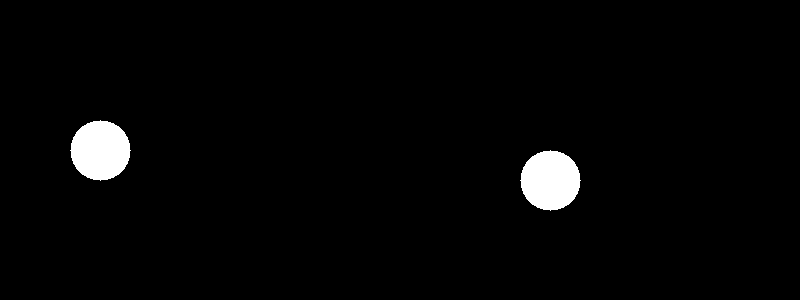

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# generate a blank black canvas for the first frame
frame1 = np.zeros((300, 400), dtype=np.uint8)

# draw a white circle acting as our moving object
cv2.circle(frame1, (100, 150), 30, 255, -1)

# create the second frame to simulate movement
frame2 = np.zeros((300, 400), dtype=np.uint8)

# shift the circle 50 pixels right and 30 pixels down
cv2.circle(frame2, (150, 180), 30, 255, -1)

# display our raw data side by side
print("Base frames for motion estimation:")
combined_frames = cv2.hconcat([frame1, frame2])
cv2_imshow(combined_frames)

### **1. Dense Optical Flow (Farnebäck Algorithm)**

Dense optical flow processes every single pixel in the image grid. Although this method requires significant computational power, it provides a comprehensive motion map.

OpenCV includes a highly optimized version of the Farnebäck algorithm. We will use it to compute our flow vectors. The output array contains both magnitude and direction data. Once we map these geometric values to the HSV color space, the overall movement becomes visually clear.


Dense optical flow visualization:


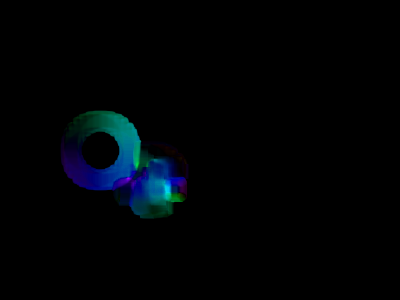

In [ ]:
# run the farneback algorithm to get dense flow vectors
flow = cv2.calcOpticalFlowFarneback(frame1, frame2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

# setup an hsv matrix to visualize the math
hsv = np.zeros((300, 400, 3), dtype=np.uint8)

# set maximum saturation for vivid colors
hsv[..., 1] = 255

# split the 2d flow matrix into polar coordinates
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

# map the calculated angle to the hue channel
hsv[..., 0] = ang * 180 / np.pi / 2

# normalize the magnitude to fit inside the value channel limits
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

# convert back to bgr so colab can render it properly
dense_result = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

print("\nDense optical flow visualization:")
cv2_imshow(dense_result)

### **2. Sparse Optical Flow (Lucas-Kanade Method)**

The Lucas-Kanade method introduces a highly efficient alternative.

Instead of calculating flow for the entire image, it tracks only specific feature points. We find prominent corners using the Shi-Tomasi detector; and the algorithm follows their coordinates across the timeline. Motion trajectories are drawn as lines between old and new pixel locations.

Since it ignores flat or featureless areas entirely, this sparse technique executes with minimal latency.


Sparse optical flow (Lucas-Kanade):


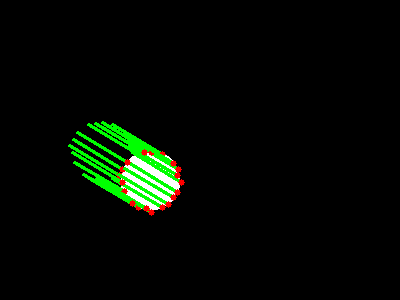

In [ ]:
# find strong corners in the initial frame to track
features = cv2.goodFeaturesToTrack(frame1, maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)

# calculate the sparse optical flow using image pyramids
next_features, status, error = cv2.calcOpticalFlowPyrLK(frame1, frame2, features, None)

# filter out the points that the algorithm successfully found in frame 2
good_new = next_features[status == 1]
good_old = features[status == 1]

# convert the second frame to color so we can draw colored tracking lines
track_img = cv2.cvtColor(frame2, cv2.COLOR_GRAY2BGR)

# loop through the tracked coordinates
for i, (new, old) in enumerate(zip(good_new, good_old)):

    # flatten the arrays to get x and y
    a, b = new.ravel()
    c, d = old.ravel()

    # cast to integers for drawing functions
    a, b, c, d = int(a), int(b), int(c), int(d)

    # draw a green motion vector line
    cv2.line(track_img, (a, b), (c, d), (0, 255, 0), 2)

    # put a red dot at the final position
    cv2.circle(track_img, (a, b), 3, (0, 0, 255), -1)

print("\nSparse optical flow (Lucas-Kanade):")
cv2_imshow(track_img)